total de linhas de apenas: (324653, 69)
------------------------------------------------------------
qtde de inscritos:


,situacao_fies,qtde_inscritos
0,CONTRATADA,7315
1,INSCRIÇÃO POSTERGADA,380
2,LISTA DE ESPERA,287584
3,NÃO CONTRATADO,16431
4,OPÇÃO NÃO CONTRATADA,2871
5,PARTICIPACAO CANCELADA PELO CANDIDATO,8870
6,PRÉ-SELECIONADO,609
7,REJEITADA PELA CPSA,593


--- Quantidade de NaNs por coluna ---
renda_per_capita                                                                                                            0
gap                                                                                                                         1
idade                                                                                                                       0
nota_corte_gp                                                                                                               0
renda_gap                                                                                                                   1
beneficiado_creduc_fies_NÃO                                                                                                 0
beneficiado_creduc_fies_SIM                                                                                                 0
modalidade_fies_Modalidade II                                                   

/home/eq_lucas/Documents/projetos/kdd-pipeline-microdata-fies/venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/eq_lucas/Documents/projetos/kdd-pipeline-microdata-fies/venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


--- Treinamento Concluído ---
Modelo salvo em: /home/eq_lucas/Documents/projetos/kdd-pipeline-microdata-fies/reports/models/analise_017_modelo_fies_logistica.pkl
Acurácia: 0.8211
ROC-AUC (OVR): 0.9366

=== Relatório de Classificação ===
              precision    recall  f1-score   support

           0       0.30      0.48      0.37     16430
           1       1.00      0.84      0.91    287584
           2       0.13      0.76      0.23      7315

    accuracy                           0.82    311329
   macro avg       0.48      0.69      0.50    311329
weighted avg       0.94      0.82      0.87    311329



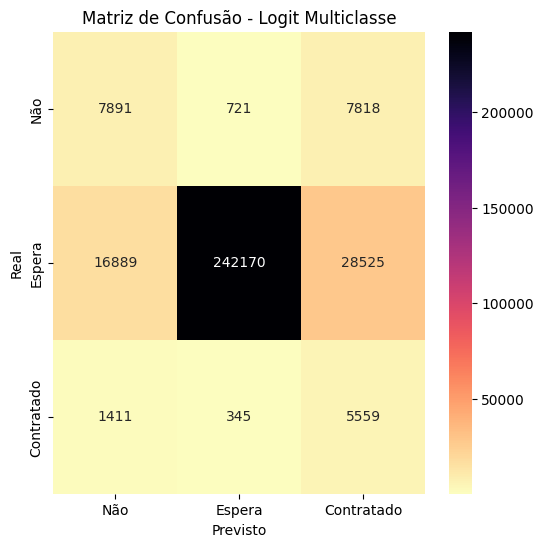


🔥 ANÁLISE REAL — MODELO MULTICLASSE (LOGIT)

[INFO] Gráfico 1 — impacto da nota dependendo da renda
[INFO] Agora mostra PROBABILIDADE REAL da classe CONTRATADO


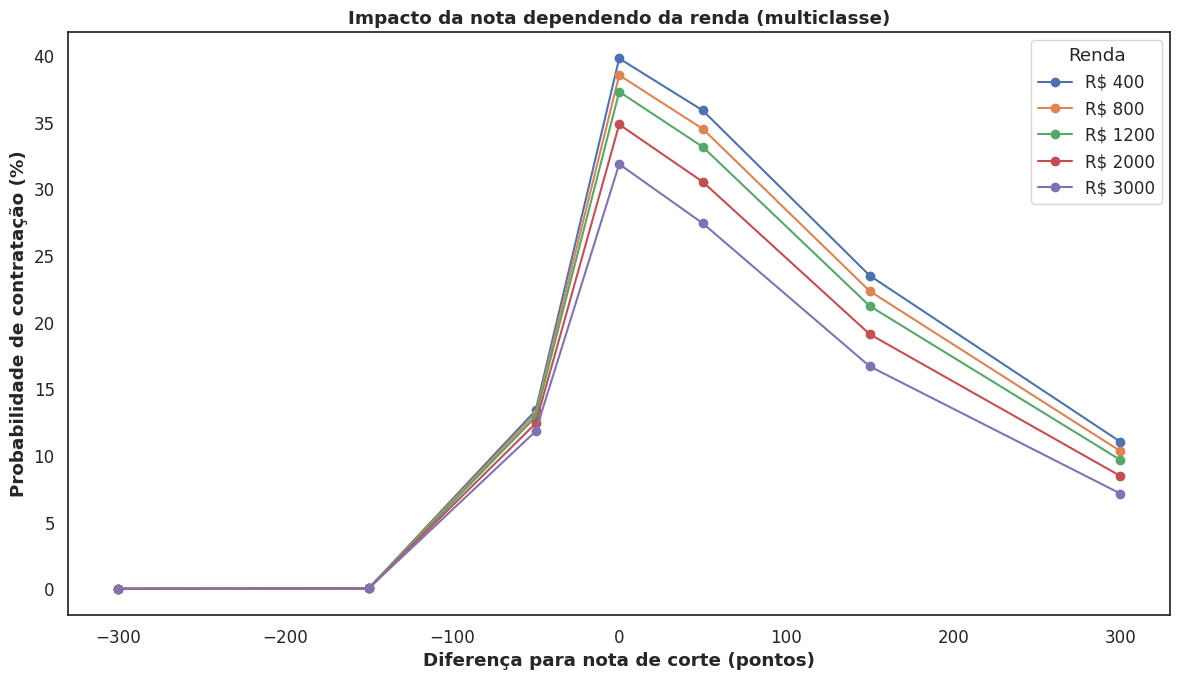


[INFO] Gráfico 2 — impacto da renda dependendo da nota


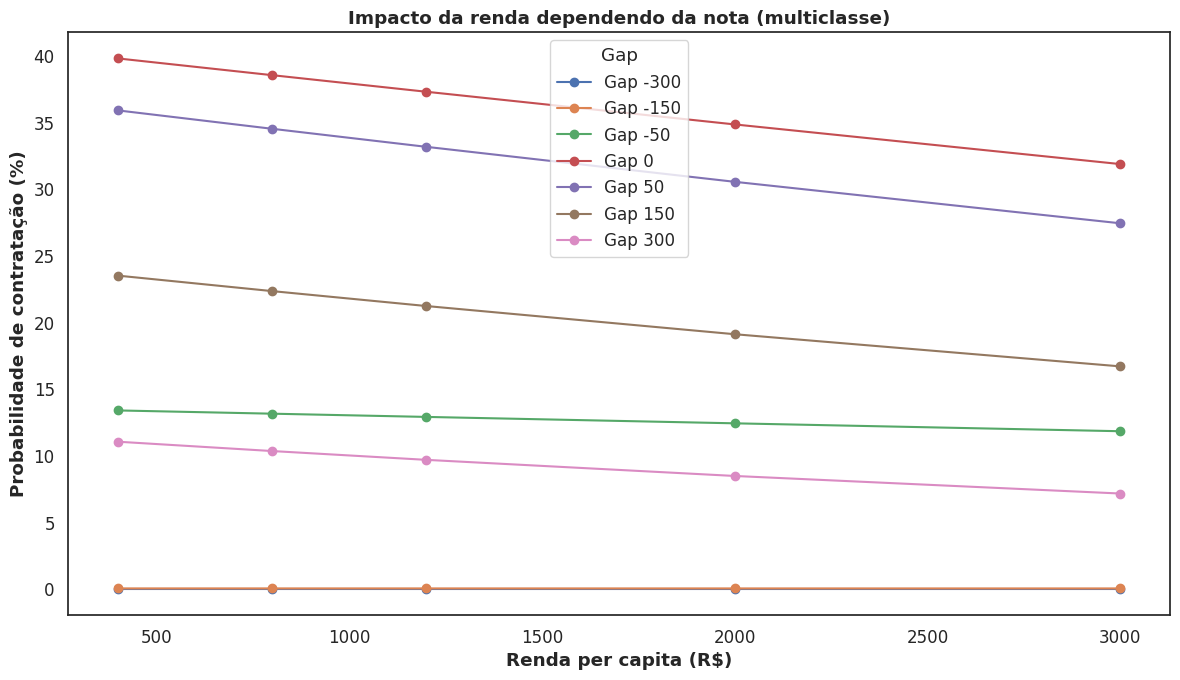


[INFO] Heatmap — Probabilidade de CONTRATADO


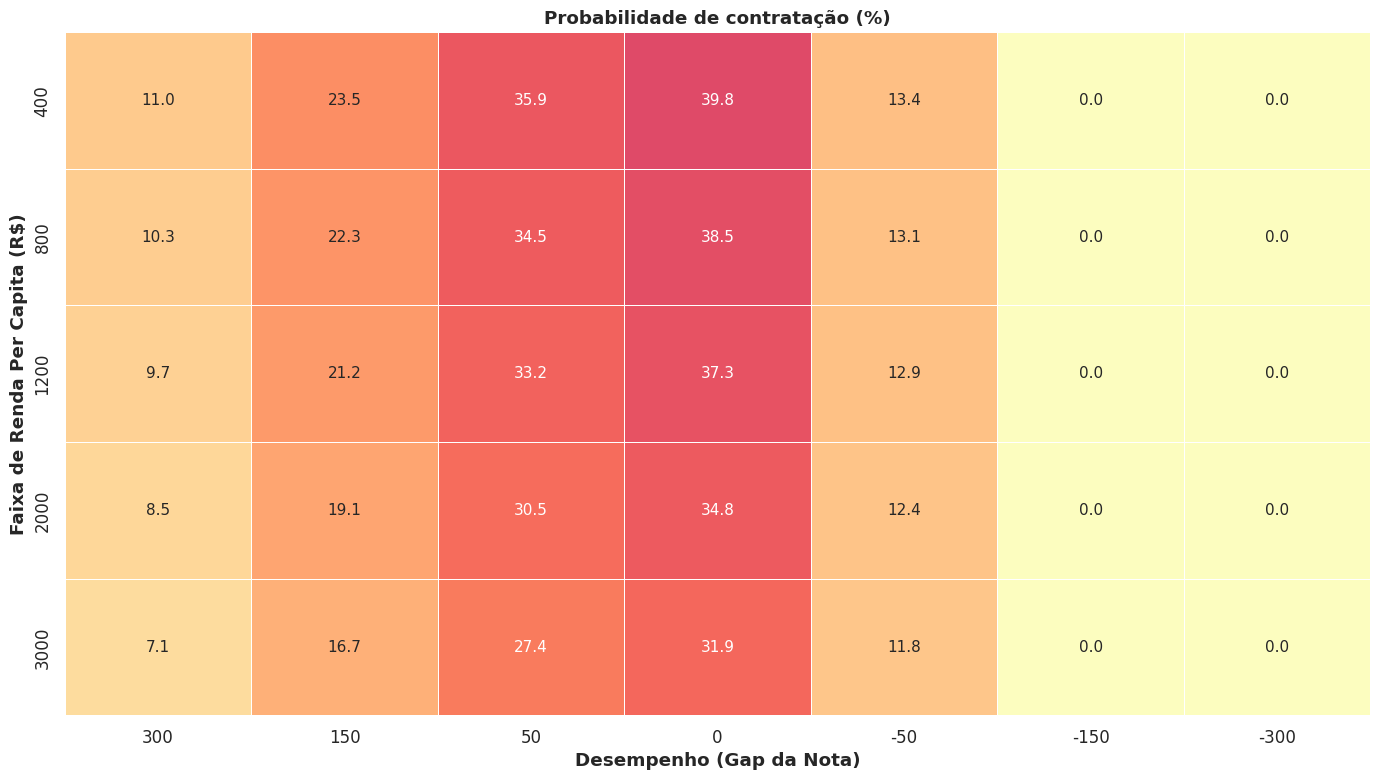


[INFO] Heatmap — DECISÃO REAL DO MODELO (classe final)


<ipython-input-1-592a2c33c3cf>:639: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  matriz_num = matriz_decisao.replace(mapa_num)


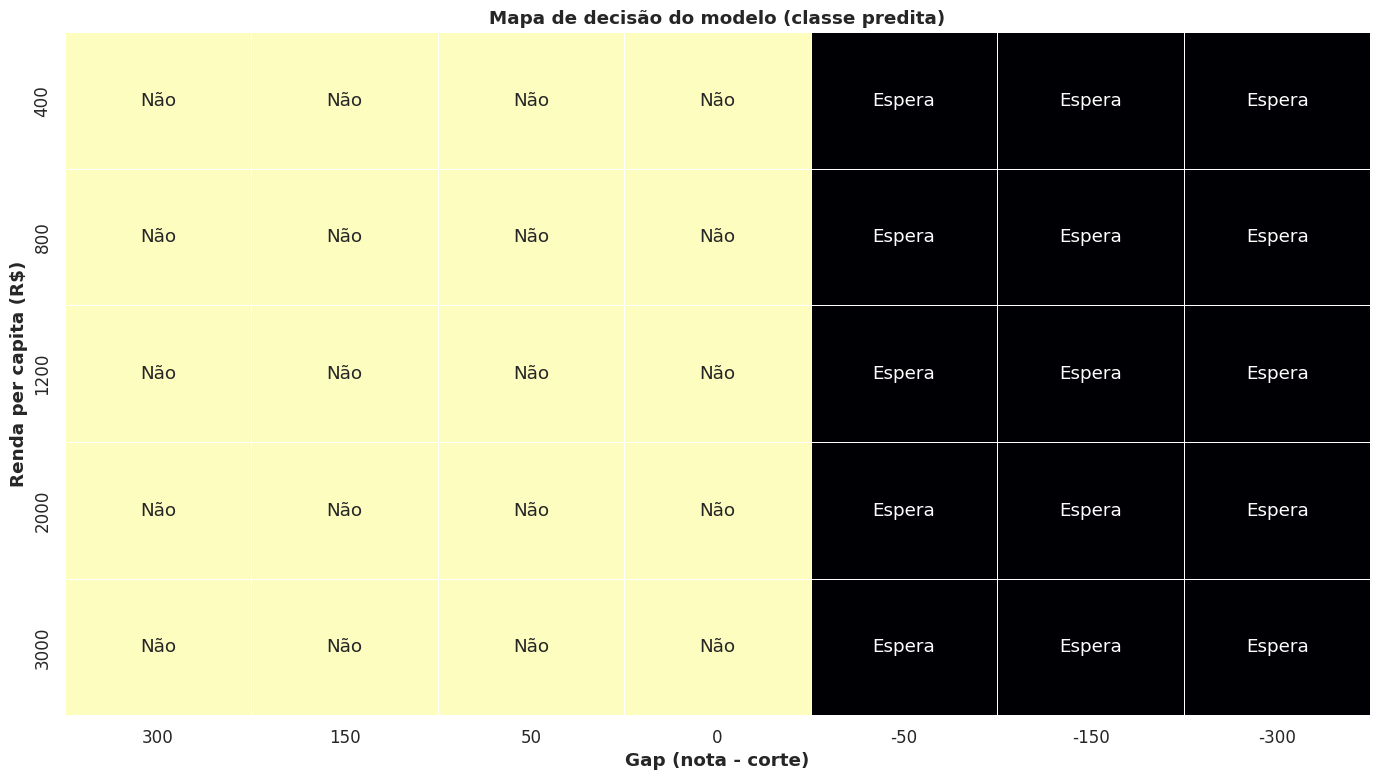


[INFO] Distribuição das classes no cenário simulado:
classe_predita
Não      57.14
Espera   42.86
Name: proportion, dtype: float64


🔥 INTERPRETAÇÃO MULTINOMIAL — REGRESSÃO LOGÍSTICA

--------------------------------------------------------------------------------
🎯 CLASSE 0
--------------------------------------------------------------------------------

📊 TOP VARIÁVEIS MAIS IMPORTANTES:
                                             variavel  coeficiente
1                                                 gap         2.33
3                                       nota_corte_gp         1.30
12                        concluiu_curso_superior_SIM        -0.54
10                                      opcao_curso_2         0.22
11                                      opcao_curso_3         0.20
15                       conceito_curso_gp_AUTORIZADO         0.20
8             modalidade_fies_Modalidade III (P-FIES)        -0.16
20  natureza_juridica_mantenedora_PESSOA JURÍDICA ...         0.15
21  

In [ ]:
# fazer roc auc
# testar o msm modelo reg logit, mas com o dataset inteiro na matriz de confusao sem distinguir anos e semestre

def orquestrador_inicial_inscritos_17():

    # 1. Gerar dados
    X, Y, X_teste, Y_teste, df_base = gerar_ABT()

    # 2. Treinar modelo
    modelo = TreinarModelo('veio_treino', X, Y)

    # 3. Avaliação principal (ROC, matriz, etc)
    acuracia_e_previsao(
        'veio', 'simm',
        modelo, X, Y, X_teste, Y_teste
    )

    # 4. Análise interpretável (🔥 agora em R$ e ENEM)
    analises_e_datasets(
        'veio_treino', 'simm',
        modelo, X, Y, X_teste, Y_teste,
        df_inicial=df_base
    )

    # 5. Visualizações exploratórias (scatter)


def orquestrador_ja_rodado_inscritos_17():

    import pandas as pd
    import joblib
    from constantes import (
        pasta_data_05_processed_analise_017_X_treino, 
        pasta_data_05_processed_analise_017_y_treino,
        pasta_modelo_analise_017,
        pasta_data_05_processed_analise_017_X_teste,
        pasta_data_05_processed_analise_017_y_teste,
        pasta_data_04_load_inscritos
    )

    # 1. Carregar dados
    X = pd.read_parquet(str(pasta_data_05_processed_analise_017_X_treino))
    Y = pd.read_parquet(str(pasta_data_05_processed_analise_017_y_treino))
    X_teste = pd.read_parquet(str(pasta_data_05_processed_analise_017_X_teste))
    Y_teste = pd.read_parquet(str(pasta_data_05_processed_analise_017_y_teste))
    df_base = pd.read_parquet(str(pasta_data_04_load_inscritos))

    # 2. Carregar modelo
    modelo = joblib.load(str(pasta_modelo_analise_017))

    # 3. Avaliação
    acuracia_e_previsao(
        'veio', 'simm',
        modelo, X, Y, X_teste, Y_teste
    )

    # 4. Análise interpretável (🔥 principal)
    analises_e_datasets(
        'veio_treino', 'simm',
        modelo, X, Y, X_teste, Y_teste,
        df_inicial=df_base
    )

    # 5. Visualização exploratória



def gerar_ABT():
    import pandas as pd
    from constantes import pasta_data_04_load_inscritos,pasta_data_05_processed_analise_017
    from sklearn.linear_model import LogisticRegression

    # Configuração de visualização
    pd.set_option('display.max_columns', None)
    pd.set_option('display.max_rows', None)

    # 1. CARREGAR OS DADOS
    df_raiz = pd.read_parquet(str(pasta_data_04_load_inscritos))

    filtro_treino_base = (df_raiz['subarea_conhecimento'] == 'MEDICINA')

    df_base = df_raiz[filtro_treino_base].copy()

    # 2. CRIAR VARIÁVEIS NOVAS (Vetorizado, muito mais rápido)
    df_base['gap'] = df_base['media_enem'] - df_base['nota_corte_gp']

    def idade(x):
        try:
            return 2026 - int(str(x).split('/')[-1])
        except:
            return None

    df_base['idade'] = df_base['data_nascimento'].apply(idade)



    print('total de linhas de apenas:', df_base.shape)



    print('-'*60)
    print('qtde de inscritos:')
    display(df_base.groupby('situacao_fies',as_index=False).size().rename(columns={'size':'qtde_inscritos'}))#type: ignore





    # 3. DUMIZAR VARIÁVEIS CATEGÓRICAS
    # Isso cria as colunas 0 e 1 e JÁ EXCLUI a 'nome_cine_area_geral' original
    df = pd.get_dummies(df_base, columns=['beneficiado_creduc_fies','modalidade_fies','subarea_conhecimento','regiao_morar','natureza_juridica_mantenedora','etnia_cor','turno','ensino_medio_escola_publica','conceito_curso_gp','concluiu_curso_superior','opcao_curso'], drop_first=True)

    # 4. FILTRAR A BASE DE DADOS
    df = df[df['situacao_fies'].isin([
    'CONTRATADA',
    'LISTA DE ESPERA',
    'NÃO CONTRATADO'
    ])].copy()
        # 2. Mapear cada situação para número
    def mapear_status(x):
        if x == 'CONTRATADA':
            return 2
        elif x == 'LISTA DE ESPERA':
            return 1
        elif x == 'NÃO CONTRATADO':
            return 0
        else:
            return None

    df['status'] = df['situacao_fies'].apply(mapear_status)


    # 6. PESCAR AS COLUNAS DUMMIES
    # O Python procura e guarda apenas as colunas que começam com esse nome
    colunas_dummies_turno = [col for col in df.columns if col.startswith('turno_')]
    
    colunas_dummies_ensino_medio_escola_publica = [col for col in df.columns if col.startswith('ensino_medio_escola_publica_')]
    colunas_dummies_etnia = [col for col in df.columns if col.startswith('etnia_cor_')]
    colunas_dummies_cine = [col for col in df.columns if col.startswith('subarea_conhecimento_')]
    colunas_dummies_regiao = [col for col in df.columns if col.startswith('regiao_morar_')]
    colunas_dummies_natureza = [col for col in df.columns if col.startswith('natureza_juridica_mantenedora_')]
    colunas_dummies_opcao_curso = [col for col in df.columns if col.startswith('opcao_curso')]
    colunas_dummies_conceito_curso = [col for col in df.columns if col.startswith('conceito_curso_gp')]
    colunas_dummies_conceito_concluiu_curso_superior = [col for col in df.columns if col.startswith('concluiu_curso_superior')]
    colunas_dummies_conceito_concluiu_modfies = [col for col in df.columns if col.startswith('modalidade_fies')]
    colunas_dummies_conceito_concluiu_BENEFcreduc = [col for col in df.columns if col.startswith('beneficiado_creduc_fies')]




    

    # 9. CRIAR A LISTA EXATA DE FEATURES
    # Juntamos as variáveis que você escolheu com as dummies
    df['renda_gap']=df['renda_per_capita'] * df['gap']

    
    features_exatas = ['renda_per_capita', 'gap','idade','nota_corte_gp','renda_gap']+ colunas_dummies_conceito_concluiu_BENEFcreduc + colunas_dummies_conceito_concluiu_modfies + colunas_dummies_opcao_curso + colunas_dummies_conceito_concluiu_curso_superior + colunas_dummies_conceito_curso + colunas_dummies_cine + colunas_dummies_regiao + colunas_dummies_natureza + colunas_dummies_etnia + colunas_dummies_turno + colunas_dummies_ensino_medio_escola_publica



    # Faz o Raio-X apenas nas colunas que vão pro modelo
    print("--- Quantidade de NaNs por coluna ---")
    print(df[features_exatas].isna().sum())

    # Isso garante que se o aluno sumir, ele some das duas listas
    df_limpo = df.dropna(subset=features_exatas).copy()




    df_treino = df_limpo
    df_teste = df_limpo


    # 8. SEPARAR O X E O Y
    # O X recebe ESTRITAMENTE as colunas da sua lista branca
    X = df_treino[features_exatas]

    # O Y recebe a sua resposta
    Y = df_treino['status']
    Y_teste = df_teste['status']



    X_teste = df_teste[features_exatas]

    # O Y recebe a sua resposta


    print('coluna x linha do X com NaN inclusos:',X.shape)

    print('coluna x linha do X sem NaN inclusos:',X.shape)




    print('-'*60)
    print(f"Registros de Treino: {len(X):,}")
    print(f"Registros de Teste: {len(X_teste):,}")

    return X,Y,X_teste,Y_teste,df_base


def TreinarModelo(treino_ou_teste_veio: str, x_treino, y_treino):

    import joblib
    from sklearn.linear_model import LogisticRegression
    from sklearn.preprocessing import StandardScaler
    from sklearn.pipeline import Pipeline
    from constantes import pasta_modelo_analise_017

    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('modelo', LogisticRegression(
            penalty='elasticnet',
            l1_ratio=0.5,
            solver='saga',
            C=0.1,
            class_weight='balanced',
            max_iter=10000,
            random_state=42,
            n_jobs=-1
        ))
    ])

    pipeline.fit(x_treino, y_treino.values.ravel())

    print('--- Treinamento Concluído ---')

    joblib.dump(pipeline, str(pasta_modelo_analise_017))
    print(f'Modelo salvo em: {str(pasta_modelo_analise_017)}')

    return pipeline



def analises_e_datasets(
    treino_ou_teste_veio: str,
    usar_modelo: str,
    modelo_vindo,
    x_treino, y_treino,
    x_teste, y_teste,
    df_inicial
):

    import joblib
    from constantes import pasta_modelo_analise_017

    X = x_treino if treino_ou_teste_veio == 'veio_treino' else x_teste

    modelo = modelo_vindo if usar_modelo == 'simm' \
        else joblib.load(str(pasta_modelo_analise_017))

    # =========================
    # 🔥 NOVO BLOCO IMPORTANTE
    # =========================

    analise_real_multiclasse(modelo, X)
    interpretacao_modelo_logit(modelo, X)

def acuracia_e_previsao(
    veio_datasets_x_e_y: str,
    usar_modelo: str,
    modelo_vindo,
    x_treino, y_treino,
    x_teste, y_teste
):
    import joblib
    import matplotlib.pyplot as plt
    import seaborn as sns
    from sklearn.metrics import (
        accuracy_score,
        confusion_matrix,
        classification_report,
        roc_auc_score
    )
    from constantes import pasta_modelo_analise_017

    # =========================
    # ESCOLHER BASE (🔥 SEMPRE USANDO BASE INTEIRA COMO VC QUER)
    # =========================

    if veio_datasets_x_e_y == 'treino':
        X = x_treino
        Y = y_treino.values.ravel()
    elif veio_datasets_x_e_y == 'teste':
        X = x_teste
        Y = y_teste.values.ravel()
    else:
        # 🔥 SEU CASO: usar dataset inteiro
        X = x_treino
        Y = y_treino.values.ravel()

    modelo = modelo_vindo if usar_modelo == 'simm' \
        else joblib.load(str(pasta_modelo_analise_017))

    # =========================
    # PREVISÕES
    # =========================

    y_pred = modelo.predict(X)
    y_probs = modelo.predict_proba(X)

    # =========================
    # MÉTRICAS
    # =========================

    acuracia = accuracy_score(Y, y_pred)

    roc = roc_auc_score(Y, y_probs, multi_class='ovr')

    print(f"Acurácia: {acuracia:.4f}")
    print(f"ROC-AUC (OVR): {roc:.4f}")

    print("\n=== Relatório de Classificação ===")
    print(classification_report(Y, y_pred))

    # =========================
    # MATRIZ DE CONFUSÃO (3x3)
    # =========================

    matriz = confusion_matrix(Y, y_pred)

    plt.figure(figsize=(6, 6))
    sns.heatmap(
        matriz,
        annot=True,
        fmt='d',
        cmap='magma_r',
        xticklabels=['Não', 'Espera', 'Contratado'],
        yticklabels=['Não', 'Espera', 'Contratado']
    )
    plt.title("Matriz de Confusão - Logit Multiclasse")
    plt.xlabel("Previsto")
    plt.ylabel("Real")
    plt.show()

def interpretacao_modelo_logit(modelo, X):
    import pandas as pd
    import numpy as np

    print("\n" + "="*80)
    print("🔥 INTERPRETAÇÃO MULTINOMIAL — REGRESSÃO LOGÍSTICA")
    print("="*80)

    modelo_logit = modelo.named_steps['modelo']

    coefs = modelo_logit.coef_              # (n_classes, n_features)
    interceptos = modelo_logit.intercept_  # (n_classes,)
    classes = modelo_logit.classes_

    # =========================
    # 📊 COEFICIENTES POR CLASSE
    # =========================

    for i, classe in enumerate(classes):

        print("\n" + "-"*80)
        print(f"🎯 CLASSE {classe}")
        print("-"*80)

        df_coef = pd.DataFrame({
            'variavel': X.columns,
            'coeficiente': coefs[i]
        })

        df_coef['abs'] = df_coef['coeficiente'].abs()
        df_coef = df_coef.sort_values('abs', ascending=False).drop(columns='abs')

        print("\n📊 TOP VARIÁVEIS MAIS IMPORTANTES:")
        print(df_coef.head(15))

        print("\n📌 INTERCEPTO:")
        print(f"{interceptos[i]:.4f}")

        # =========================
        # 🔥 INTERPRETAÇÃO DIRETA
        # =========================

        def get_coef(nome):
            val = df_coef[df_coef['variavel'] == nome]['coeficiente']
            return val.values[0] if len(val) else 0

        coef_renda = get_coef('renda_per_capita')
        coef_gap = get_coef('gap')
        coef_interacao = get_coef('renda_gap')

        print("\n🧠 INTERPRETAÇÃO DOS PRINCIPAIS EFEITOS")

        print(f"""
📈 GAP:
{coef_gap:.4f}
→ Aumentar nota impacta essa classe {'POSITIVAMENTE' if coef_gap > 0 else 'NEGATIVAMENTE'}
""")

        print(f"""
💰 RENDA:
{coef_renda:.4f}
→ Aumentar renda impacta essa classe {'POSITIVAMENTE' if coef_renda > 0 else 'NEGATIVAMENTE'}
""")

        print(f"""
🔥 INTERAÇÃO (RENDA × GAP):
{coef_interacao:.4f}
→ Interação é {'FORTE' if abs(coef_interacao) > 0.01 else 'FRACA'}

→ Sinal {'POSITIVO' if coef_interacao > 0 else 'NEGATIVO'}
""")

    # =========================
    # 🔥 COMPARAÇÃO ENTRE CLASSES
    # =========================

    print("\n" + "="*80)
    print("⚔️ COMPARAÇÃO ENTRE CLASSES")
    print("="*80)

    df_full = pd.DataFrame(coefs, columns=X.columns, index=classes)

    # ranking global de importância (média absoluta)
    importancia = df_full.abs().mean().sort_values(ascending=False)

    print("\n🏆 VARIÁVEIS MAIS IMPORTANTES NO MODELO (GERAL):")
    print(importancia.head(15))

    print("\n📊 COMO CADA VARIÁVEL MUDA ENTRE CLASSES:")

    for var in importancia.head(10).index:
        valores = df_full[var]

        print(f"\n🔹 {var}")
        for cls in classes:
            print(f"Classe {cls}: {valores[cls]:.4f}")

    print("\n" + "="*80)
    print("🧠 LEITURA CORRETA (MULTINOMIAL)")
    print("="*80)

    print("""
- Cada linha (classe) é um modelo vs baseline interno
- Coeficiente positivo → aumenta chance daquela classe
- Coeficiente negativo → reduz chance daquela classe

⚠️ IMPORTANTE:
As classes COMPETEM entre si

→ aumentar prob de uma diminui das outras

🔥 REGRA DE OURO:
Nunca interprete coeficiente isolado
Sempre compare entre classes
""")
    
def analise_real_multiclasse(modelo, X):
    from pathlib import Path
    import pandas as pd
    import matplotlib.pyplot as plt
    import seaborn as sns
    import numpy as np

    # ==============================================================================
    # 1. CONFIGURAÇÕES VISUAIS (🔥 MESMO PADRÃO)
    # ==============================================================================

    pd.set_option('display.max_rows', 100)
    pd.set_option('display.max_columns', None)
    pd.set_option('display.width', 1000)
    pd.set_option('display.float_format', '{:.2f}'.format)

    sns.set_theme(style="white", font_scale=1.1)

    pasta_figuras = Path('reports/figures/analise_017').resolve()
    pasta_figuras.mkdir(parents=True, exist_ok=True)

    print("\n" + "="*80)
    print("🔥 ANÁLISE REAL — MODELO MULTICLASSE (LOGIT)")
    print("="*80)

    # ==============================================================================
    # 2. GRID REALISTA (igual ao seu)
    # ==============================================================================

    rendas = [400, 800, 1200, 2000, 3000]
    gaps = [-300, -150, -50, 0, 50, 150, 300]

    valores_medios = X.mean(numeric_only=True)
    mediana_idade = X['idade'].median()
    mediana_nota_corte = X['nota_corte_gp'].median()

    linhas = []

    for renda in rendas:
        for gap in gaps:
            linha = {}

            for col in X.columns:
                if col == 'renda_per_capita':
                    linha[col] = renda
                elif col == 'gap':
                    linha[col] = gap
                elif col == 'renda_gap':
                    linha[col] = renda * gap
                elif col == 'idade':
                    linha[col] = mediana_idade
                elif col == 'nota_corte_gp':
                    linha[col] = mediana_nota_corte
                else:
                    linha[col] = valores_medios.get(col, 0)

            linhas.append(linha)

    df_real = pd.DataFrame(linhas).reindex(columns=X.columns, fill_value=0)

    # ==============================================================================
    # 3. PROBABILIDADES E CLASSES
    # ==============================================================================

    modelo_logit = modelo.named_steps['modelo']
    classes = modelo_logit.classes_

    probs = modelo.predict_proba(df_real)
    preds = modelo.predict(df_real)

    mapa_classes = {
        0: 'Não',
        1: 'Espera',
        2: 'Contratado'
    }

    df_real['classe_predita'] = [mapa_classes.get(x, x) for x in preds]

    for i, cls in enumerate(classes):
        nome = mapa_classes.get(cls, str(cls))
        df_real[f'prob_{nome}'] = probs[:, i] * 100

    # ==============================================================================
    # 4. 📈 GRÁFICO 1 — IMPACTO DA NOTA (🔥 IGUAL AO SEU, MAS CORRETO)
    # ==============================================================================

    print("\n[INFO] Gráfico 1 — impacto da nota dependendo da renda")
    print("[INFO] Agora mostra PROBABILIDADE REAL da classe CONTRATADO")

    plt.figure(figsize=(12, 7))

    for renda in rendas:
        subset = df_real[df_real['renda_per_capita'] == renda].sort_values('gap')

        plt.plot(
            subset['gap'],
            subset['prob_Contratado'],
            marker='o',
            label=f'R$ {renda}'
        )

    plt.xlabel('Diferença para nota de corte (pontos)', fontweight='bold')
    plt.ylabel('Probabilidade de contratação (%)', fontweight='bold')
    plt.title('Impacto da nota dependendo da renda (multiclasse)', fontweight='bold')
    plt.legend(title='Renda')
    plt.tight_layout()
    plt.savefig(pasta_figuras / 'curvas_multiclasse_nota.png', dpi=300)
    plt.show()

    # ==============================================================================
    # 5. 📈 GRÁFICO 2 — IMPACTO DA RENDA
    # ==============================================================================

    print("\n[INFO] Gráfico 2 — impacto da renda dependendo da nota")

    plt.figure(figsize=(12, 7))

    for gap in gaps:
        subset = df_real[df_real['gap'] == gap].sort_values('renda_per_capita')

        plt.plot(
            subset['renda_per_capita'],
            subset['prob_Contratado'],
            marker='o',
            label=f'Gap {gap}'
        )

    plt.xlabel('Renda per capita (R$)', fontweight='bold')
    plt.ylabel('Probabilidade de contratação (%)', fontweight='bold')
    plt.title('Impacto da renda dependendo da nota (multiclasse)', fontweight='bold')
    plt.legend(title='Gap')
    plt.tight_layout()
    plt.savefig(pasta_figuras / 'curvas_multiclasse_renda.png', dpi=300)
    plt.show()

    # ==============================================================================
    # 6. 🔥 HEATMAP — PROBABILIDADE
    # ==============================================================================

    print("\n[INFO] Heatmap — Probabilidade de CONTRATADO")

    matriz_prob = df_real.pivot(
        index='renda_per_capita',
        columns='gap',
        values='prob_Contratado'
    ).reindex(index=rendas, columns=gaps[::-1])

    plt.figure(figsize=(14, 8))

    sns.heatmap(
        matriz_prob,
        annot=True,
        fmt=".1f",
        cmap="magma_r",
        vmin=0,
        vmax=100,
        linewidths=0.5,
        linecolor='white',
        annot_kws={"size": 11},
        cbar=False
    )

    plt.ylabel('Faixa de Renda Per Capita (R$)', fontweight='bold')
    plt.xlabel('Desempenho (Gap da Nota)', fontweight='bold')
    plt.title('Probabilidade de contratação (%)', fontweight='bold')

    plt.tight_layout()
    plt.savefig(pasta_figuras / 'heatmap_multiclasse_prob.png', dpi=300)
    plt.show()

    # ==============================================================================
    # 7. 🔥 MAPA DE DECISÃO REAL (ESSA É A DIFERENÇA!)
    # ==============================================================================

    print("\n[INFO] Heatmap — DECISÃO REAL DO MODELO (classe final)")

    matriz_decisao = df_real.pivot(
        index='renda_per_capita',
        columns='gap',
        values='classe_predita'
    ).reindex(index=rendas, columns=gaps[::-1])

    mapa_num = {'Não': 0, 'Espera': 1, 'Contratado': 2}
    matriz_num = matriz_decisao.replace(mapa_num)

    plt.figure(figsize=(14, 8))

    sns.heatmap(
        matriz_num,
        annot=matriz_decisao,
        fmt='',
        cmap='magma_r',
        linewidths=0.5,
        linecolor='white',
        cbar=False
    )

    plt.ylabel('Renda per capita (R$)', fontweight='bold')
    plt.xlabel('Gap (nota - corte)', fontweight='bold')
    plt.title('Mapa de decisão do modelo (classe predita)', fontweight='bold')

    plt.tight_layout()
    plt.savefig(pasta_figuras / 'heatmap_multiclasse_decisao.png', dpi=300)
    plt.show()

    # ==============================================================================
    # 8. 🔥 DISTRIBUIÇÃO FINAL
    # ==============================================================================

    print("\n[INFO] Distribuição das classes no cenário simulado:")

    dist = df_real['classe_predita'].value_counts(normalize=True) * 100
    print(dist)

    print("\n" + "="*80)

orquestrador_inicial_inscritos_17()